In [1]:
import requests
import sys
sys.path.append("..")
from config import NASS_API_KEY, NASS_BASE_URL
from utils import FINAL_CROPS          # tu diccionario central
# from utils import CROP_TO_NASS       # si lo añades a utils
# o defínelo aquí si prefieres tenerlo cerca del código de rendimiento

# Mapeo a nombres NASS (usa el mismo crop_id que FINAL_CROPS)
CROP_TO_NASS = {
    75: "ALMONDS", 69: "GRAPES", 204: "PISTACHIOS", 76: "WALNUTS",
    54: "TOMATOES", 3: "RICE", 2: "COTTON", 227: "LETTUCE",
    221: "STRAWBERRIES", 212: "ORANGES", 36: "HAY", 24: "WHEAT",
}

def explorar_cultivo(crop_id):
    commodity = CROP_TO_NASS[crop_id]
    nombre_propio = FINAL_CROPS[crop_id]   # tu nombre, para mostrar
    params = {
        "key": NASS_API_KEY,
        "commodity_desc": commodity,
        "state_alpha": "CA",
        "statisticcat_desc": "YIELD",
        "agg_level_desc": "COUNTY",
        "format": "JSON",
    }
    r = requests.get(NASS_BASE_URL, params=params)
    if r.status_code != 200:
        return f"  Error {r.status_code}"
    data = r.json().get("data", [])
    if not data:
        return "  Sin datos de rendimiento por condado"
    anios = sorted(set(d["year"] for d in data))
    unidades = sorted(set(d.get("unit_desc", "?") for d in data))
    return f"  {len(data)} registros | años {anios[0]}-{anios[-1]} | unidades: {unidades}"

# Explorar usando tu diccionario central
for crop_id, nombre in FINAL_CROPS.items():
    print(f"{nombre} (NASS: {CROP_TO_NASS[crop_id]}):")
    print(explorar_cultivo(crop_id))

Almonds (NASS: ALMONDS):
  Error 400
Grapes (NASS: GRAPES):
  Error 400
Pistachios (NASS: PISTACHIOS):
  Error 400
Walnuts (NASS: WALNUTS):
  Error 400
Tomatoes (NASS: TOMATOES):
  340 registros | años 1989-2025 | unidades: ['TONS / ACRE']
Rice (NASS: RICE):
  1285 registros | años 1953-2025 | unidades: ['LB / ACRE', 'LB / NET PLANTED ACRE']
Cotton (NASS: COTTON):
  1476 registros | años 1919-2025 | unidades: ['LB / ACRE', 'LB / NET PLANTED ACRE']
Lettuce (NASS: LETTUCE):
  Error 400
Strawberries (NASS: STRAWBERRIES):
  Error 400
Oranges (NASS: ORANGES):
  Error 400
Alfalfa (NASS: HAY):
  Error 400
Wheat (NASS: WHEAT):
  19023 registros | años 1945-2025 | unidades: ['BU / ACRE', 'BU / NET PLANTED ACRE']


In [2]:
def explorar_cultivo_acotado(crop_id, anio_desde=2010):
    commodity = CROP_TO_NASS[crop_id]
    params = {
        "key": NASS_API_KEY,
        "commodity_desc": commodity,
        "state_alpha": "CA",
        "statisticcat_desc": "YIELD",
        "agg_level_desc": "COUNTY",
        "year__GE": str(anio_desde),   # año mayor o igual a
        "format": "JSON",
    }
    r = requests.get(NASS_BASE_URL, params=params)
    if r.status_code != 200:
        return f"  Error {r.status_code}"
    data = r.json().get("data", [])
    if not data:
        return "  Sin datos"
    anios = sorted(set(d["year"] for d in data))
    unidades = sorted(set(d.get("unit_desc", "?") for d in data))
    return f"  {len(data)} registros | años {anios[0]}-{anios[-1]} | unidades: {unidades}"

for crop_id, nombre in FINAL_CROPS.items():
    print(f"{nombre}:")
    print(explorar_cultivo_acotado(crop_id, 2010))

Almonds:
  Error 400
Grapes:
  Error 400
Pistachios:
  Error 400
Walnuts:
  Error 400
Tomatoes:
  259 registros | años 2010-2025 | unidades: ['TONS / ACRE']
Rice:
  138 registros | años 2010-2025 | unidades: ['LB / ACRE']
Cotton:
  148 registros | años 2010-2025 | unidades: ['LB / ACRE']
Lettuce:
  Error 400
Strawberries:
  Error 400
Oranges:
  Error 400
Alfalfa:
  Error 400
Wheat:
  235 registros | años 2010-2025 | unidades: ['BU / ACRE']


In [3]:
def contar_registros(crop_id, anio_desde=2010):
    commodity = CROP_TO_NASS[crop_id]
    params = {
        "key": NASS_API_KEY,
        "commodity_desc": commodity,
        "state_alpha": "CA",
        "statisticcat_desc": "YIELD",
        "agg_level_desc": "COUNTY",
        "year__GE": str(anio_desde),
    }
    r = requests.get("https://quickstats.nass.usda.gov/api/get_counts/", params=params)
    if r.status_code == 200:
        return r.json().get("count", "?")
    return f"Error {r.status_code}"

for crop_id, nombre in FINAL_CROPS.items():
    print(f"{nombre}: {contar_registros(crop_id)}")

Almonds: 0
Grapes: 0
Pistachios: 0
Walnuts: 0
Tomatoes: 259
Rice: 138
Cotton: 148
Lettuce: 0
Strawberries: 0
Oranges: 0
Alfalfa: 0
Wheat: 235


In [4]:
def ver_estadisticas(crop_id, anio_desde=2022):
    """Ver qué estadísticas (statisticcat) hay para un cultivo, sin filtrar por YIELD."""
    commodity = CROP_TO_NASS[crop_id]
    params = {
        "key": NASS_API_KEY,
        "commodity_desc": commodity,
        "state_alpha": "CA",
        "agg_level_desc": "COUNTY",
        "year__GE": str(anio_desde),  # pocos años para que quepa
        "format": "JSON",
    }
    r = requests.get(NASS_BASE_URL, params=params)
    if r.status_code != 200:
        return f"  Error {r.status_code}"
    data = r.json().get("data", [])
    if not data:
        return "  Sin datos a nivel de condado"
    stats = sorted(set(d.get("statisticcat_desc", "?") for d in data))
    return f"  {len(data)} registros | estadísticas disponibles: {stats}"

# Ver qué hay para los frutales
for crop_id in [75, 69, 204, 76, 212]:  # Almendras, Uvas, Pistachos, Nueces, Naranjas
    print(f"{FINAL_CROPS[crop_id]} (NASS: {CROP_TO_NASS[crop_id]}):")
    print(ver_estadisticas(crop_id, 2022))
    print()

Almonds (NASS: ALMONDS):
  294 registros | estadísticas disponibles: ['AREA BEARING', 'AREA BEARING & NON-BEARING', 'AREA NON-BEARING']

Grapes (NASS: GRAPES):
  409 registros | estadísticas disponibles: ['AREA BEARING', 'AREA BEARING & NON-BEARING', 'AREA NON-BEARING']

Pistachios (NASS: PISTACHIOS):
  199 registros | estadísticas disponibles: ['AREA BEARING', 'AREA BEARING & NON-BEARING', 'AREA NON-BEARING']

Walnuts (NASS: WALNUTS):
  312 registros | estadísticas disponibles: ['AREA BEARING', 'AREA BEARING & NON-BEARING', 'AREA NON-BEARING']

Oranges (NASS: ORANGES):
  636 registros | estadísticas disponibles: ['AREA BEARING', 'AREA BEARING & NON-BEARING', 'AREA NON-BEARING']



In [5]:
def buscar_commodity(texto, anio=2023):
    """Buscar qué nombres de commodity existen relacionados con un texto."""
    params = {
        "key": NASS_API_KEY,
        "state_alpha": "CA",
        "agg_level_desc": "COUNTY",
        "year": str(anio),
        "format": "JSON",
    }
    r = requests.get(NASS_BASE_URL, params=params)
    # Este endpoint puede ser muy grande; mejor usar get_param_values
    # Alternativa: consultar valores posibles del parámetro commodity_desc

# Mejor: obtener los valores válidos de commodity_desc
def valores_commodity():
    params = {
        "key": NASS_API_KEY,
        "param": "commodity_desc",
    }
    r = requests.get("https://quickstats.nass.usda.gov/api/get_param_values/", params=params)
    if r.status_code == 200:
        vals = r.json().get("commodity_desc", [])
        # Filtrar los que nos interesan
        for busca in ["ALMOND", "GRAPE", "PISTACHIO", "WALNUT", "ORANGE", "STRAWBERR", "LETTUCE", "HAY"]:
            coincidencias = [v for v in vals if busca in v.upper()]
            print(f"{busca}: {coincidencias}")
    return

valores_commodity()

ALMOND: ['ALMONDS']
GRAPE: ['GRAPEFRUIT', 'GRAPES']
PISTACHIO: ['PISTACHIOS']
WALNUT: ['WALNUTS']
ORANGE: ['ORANGES']
STRAWBERR: ['STRAWBERRIES']
LETTUCE: ['LETTUCE']
HAY: ['FEED GRAINS & HAY', 'HAY', 'HAY & HAYLAGE', 'HAYLAGE']


In [6]:
def ver_yield_estatal(crop_id, anio_desde=2010):
    """Ver si hay YIELD a nivel ESTATAL (no condado) para un cultivo."""
    commodity = CROP_TO_NASS[crop_id]
    params = {
        "key": NASS_API_KEY,
        "commodity_desc": commodity,
        "state_alpha": "CA",
        "statisticcat_desc": "YIELD",
        "agg_level_desc": "STATE",   # ESTADO, no condado
        "year__GE": str(anio_desde),
        "format": "JSON",
    }
    r = requests.get(NASS_BASE_URL, params=params)
    if r.status_code != 200:
        return f"  Error {r.status_code}"
    data = r.json().get("data", [])
    if not data:
        return "  Sin yield estatal"
    anios = sorted(set(d["year"] for d in data))
    unidades = sorted(set(d.get("unit_desc", "?") for d in data))
    clases = sorted(set(d.get("class_desc", "?") for d in data))
    return f"  {len(data)} registros | años {anios[0]}-{anios[-1]} | unidades: {unidades} | clases: {clases}"

for crop_id in [75, 69, 204, 76, 212]:  # frutales
    print(f"{FINAL_CROPS[crop_id]}:")
    print(ver_yield_estatal(crop_id, 2010))
    print()

Almonds:
  26 registros | años 2010-2026 | unidades: ['LB / ACRE'] | clases: ['ALL CLASSES']

Grapes:
  64 registros | años 2010-2025 | unidades: ['TONS / ACRE'] | clases: ['ALL CLASSES', 'RAISIN TYPE', 'TABLE TYPE', 'WINE TYPE']

Pistachios:
  20 registros | años 2010-2025 | unidades: ['LB / ACRE', 'TONS / ACRE'] | clases: ['ALL CLASSES']

Walnuts:
  17 registros | años 2010-2025 | unidades: ['TONS / ACRE'] | clases: ['ENGLISH']

Oranges:
  49 registros | años 2010-2025 | unidades: ['BOXES / ACRE'] | clases: ['ALL CLASSES', 'MID & NAVEL', 'VALENCIA']



In [7]:
def ver_produccion_condado(crop_id, anio_desde=2020):
    """¿Hay PRODUCTION a nivel de condado para este cultivo?"""
    commodity = CROP_TO_NASS[crop_id]
    params = {
        "key": NASS_API_KEY,
        "commodity_desc": commodity,
        "state_alpha": "CA",
        "statisticcat_desc": "PRODUCTION",
        "agg_level_desc": "COUNTY",
        "year__GE": str(anio_desde),
        "format": "JSON",
    }
    r = requests.get(NASS_BASE_URL, params=params)
    if r.status_code != 200:
        return f"  Error {r.status_code}"
    data = r.json().get("data", [])
    if not data:
        return "  Sin producción por condado"
    anios = sorted(set(d["year"] for d in data))
    unidades = sorted(set(d.get("unit_desc", "?") for d in data))
    return f"  {len(data)} registros | años {anios[0]}-{anios[-1]} | unidades: {unidades}"

for crop_id in [75, 69, 204, 76, 212]:  # frutales
    print(f"{FINAL_CROPS[crop_id]}:")
    print(ver_produccion_condado(crop_id, 2020))
    print()

Almonds:
  Error 400

Grapes:
  Error 400

Pistachios:
  Error 400

Walnuts:
  Error 400

Oranges:
  Error 400



In [8]:
def contar(crop_id, stat):
    commodity = CROP_TO_NASS[crop_id]
    params = {
        "key": NASS_API_KEY,
        "commodity_desc": commodity,
        "state_alpha": "CA",
        "statisticcat_desc": stat,
        "agg_level_desc": "COUNTY",
    }
    r = requests.get("https://quickstats.nass.usda.gov/api/get_counts/", params=params)
    return r.json().get("count", "?") if r.status_code == 200 else f"Error {r.status_code}"

for crop_id in [75, 69, 204, 76, 212]:
    print(f"{FINAL_CROPS[crop_id]}: PRODUCTION={contar(crop_id,'PRODUCTION')}, AREA HARVESTED={contar(crop_id,'AREA HARVESTED')}")

Almonds: PRODUCTION=0, AREA HARVESTED=0
Grapes: PRODUCTION=0, AREA HARVESTED=0
Pistachios: PRODUCTION=0, AREA HARVESTED=0
Walnuts: PRODUCTION=0, AREA HARVESTED=0
Oranges: PRODUCTION=0, AREA HARVESTED=0


In [9]:
def ver_fuentes(crop_id, anio_desde=2020):
    """Ver qué fuentes (source_desc) tienen datos para un frutal a nivel condado."""
    commodity = CROP_TO_NASS[crop_id]
    params = {
        "key": NASS_API_KEY,
        "commodity_desc": commodity,
        "state_alpha": "CA",
        "agg_level_desc": "COUNTY",
        "year__GE": str(anio_desde),
        "format": "JSON",
    }
    r = requests.get(NASS_BASE_URL, params=params)
    if r.status_code != 200:
        return f"  Error {r.status_code}"
    data = r.json().get("data", [])
    fuentes = sorted(set(d.get("source_desc", "?") for d in data))
    stats = sorted(set(d.get("statisticcat_desc", "?") for d in data))
    return f"  Fuentes: {fuentes}\n  Estadísticas: {stats}"

for crop_id in [75, 69, 204]:  # Almendras, Uvas, Pistachos
    print(f"{FINAL_CROPS[crop_id]}:")
    print(ver_fuentes(crop_id, 2020))
    print()

Almonds:
  Fuentes: ['CENSUS']
  Estadísticas: ['AREA BEARING', 'AREA BEARING & NON-BEARING', 'AREA NON-BEARING']

Grapes:
  Fuentes: ['CENSUS']
  Estadísticas: ['AREA BEARING', 'AREA BEARING & NON-BEARING', 'AREA NON-BEARING']

Pistachios:
  Fuentes: ['CENSUS']
  Estadísticas: ['AREA BEARING', 'AREA BEARING & NON-BEARING', 'AREA NON-BEARING']



In [10]:
def ver_produccion_censo(crop_id, anio_desde=2017):
    commodity = CROP_TO_NASS[crop_id]
    params = {
        "key": NASS_API_KEY,
        "commodity_desc": commodity,
        "state_alpha": "CA",
        "agg_level_desc": "COUNTY",
        "statisticcat_desc": "PRODUCTION",
        "source_desc": "CENSUS",   # la fuente de los comisionados suele estar aquí
        "year__GE": str(anio_desde),
        "format": "JSON",
    }
    r = requests.get(NASS_BASE_URL, params=params)
    if r.status_code != 200:
        return f"  Error {r.status_code}"
    data = r.json().get("data", [])
    if not data:
        return "  Sin datos con source CENSUS"
    anios = sorted(set(d["year"] for d in data))
    unidades = sorted(set(d.get("unit_desc", "?") for d in data))
    return f"  {len(data)} registros | años {anios[0]}-{anios[-1]} | unidades: {unidades}"

for crop_id in [75, 69, 204, 76, 212]:
    print(f"{FINAL_CROPS[crop_id]}:")
    print(ver_produccion_censo(crop_id, 2017))
    print()

Almonds:
  Error 400

Grapes:
  Error 400

Pistachios:
  Error 400

Walnuts:
  Error 400

Oranges:
  Error 400



In [11]:
import polars as pl
df = pl.read_parquet(r"C:\Users\lesli\Documents\TFM\Data\base_california_app.parquet")

# ¿Qué variables tienen más nulos?
print("Nulos por variable clave:")
for col in ["tmax", "tmin", "ppt", "ph1to1h2o_r", "profundidad_efectiva_cm"]:
    n = df.filter(pl.col(col).is_null()).height
    print(f"  {col}: {n:,} nulos ({100*n/df.height:.1f}%)")

# ¿Cuántos puntos tienen clima pero NO suelo? (los recuperables)
tiene_clima = df.filter(pl.col("tmax").is_not_null())
print(f"\nPuntos con clima: {tiene_clima.height:,}")
sin_suelo = tiene_clima.filter(pl.col("ph1to1h2o_r").is_null())
print(f"  De esos, sin suelo: {sin_suelo.height:,}")

Nulos por variable clave:
  tmax: 13,107 nulos (23.0%)
  tmin: 13,107 nulos (23.0%)
  ppt: 13,107 nulos (23.0%)
  ph1to1h2o_r: 30,826 nulos (54.1%)
  profundidad_efectiva_cm: 30,746 nulos (53.9%)

Puntos con clima: 43,893
  De esos, sin suelo: 17,719


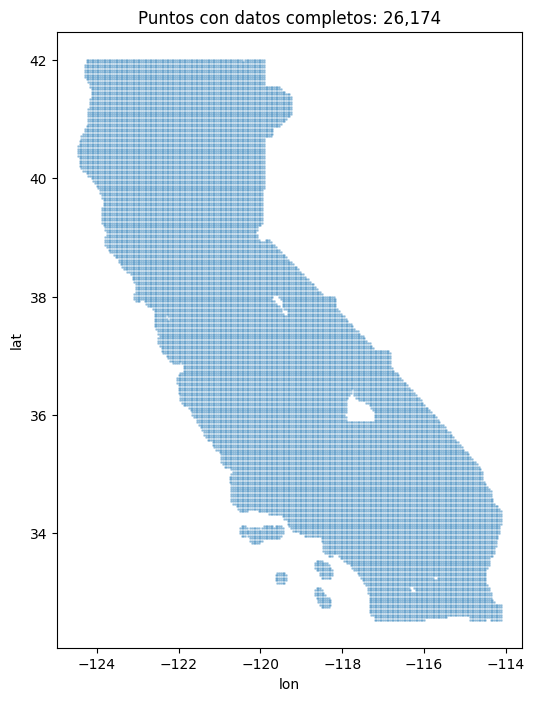

In [12]:
import matplotlib.pyplot as plt
completos = df.filter(pl.col("datos_completos") == True)
plt.figure(figsize=(6, 8))
plt.scatter(completos["lon"], completos["lat"], s=1, alpha=0.3)
plt.title(f"Puntos con datos completos: {completos.height:,}")
plt.xlabel("lon"); plt.ylabel("lat")
plt.savefig("cobertura_california.png", dpi=100)
plt.show()

In [13]:
import polars as pl
df = pl.read_parquet(r"C:\Users\lesli\Documents\TFM\Data\base_california_app.parquet")

# ¿Los puntos con clima pero sin suelo tienen vecinos con suelo cerca?
# Si el relleno funcionó, no deberían quedar tantos sin suelo en tierra
tierra = df.filter(pl.col("tmax").is_not_null())
print(f"Puntos en tierra: {tierra.height:,}")
print(f"  Con suelo: {tierra.filter(pl.col('ph1to1h2o_r').is_not_null()).height:,}")
print(f"  Sin suelo: {tierra.filter(pl.col('ph1to1h2o_r').is_null()).height:,}")

Puntos en tierra: 43,893
  Con suelo: 26,174
  Sin suelo: 17,719


In [14]:
    # 5. Rellenar faltantes con vecino cercano
    # Clima: umbral estricto (varía más en el espacio)
    cols_clima = ELEMENTOS_PRISM + cols_fut
    df = rellenar_vecino_cercano(df, cols_clima, umbral_grados=0.1)

    # Suelo: umbral más amplio (varía más suavemente, se puede extrapolar más)
    cols_suelo = SOIL_ELEMENTS + ["profundidad_efectiva_cm"]
    df = rellenar_vecino_cercano(df, cols_suelo, umbral_grados=0.3)  # ~33 km

NameError: name 'ELEMENTOS_PRISM' is not defined